In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [2]:
import json
import torch 
from src.config import CHECKPOINT_DIR
from scripts.common.get_device import get_available_device
from src.rwf2000 import RWF2000PoseDataset, RWF2000Dataset
from src.Skeleton_model.graph import SkeletonGraph, compute_joint_distance_to_center_of_gravity
from src.config import DEFAULT_STGCN_PARAMS_V1, POSE_DATASET_ROOT, DATASET_ROOT, POSE_DATASET_ROOT_OCSORT2
from src.Skeleton_model.stgcn import STGCN
from src.XAI.joint_person_occlusion import JointOcclusion
from src.XAI.plotting_functions import plot_joint_occlusion, save_joint_occlusion_video


In [3]:
experiment_root = CHECKPOINT_DIR / "STGCN_V1" / "final_seed_search_updated_masked_bn" / "final_seed45"
dataset_root = POSE_DATASET_ROOT_OCSORT2
device = get_available_device()

with open(experiment_root / "config.json", "r") as f:
    hyperparameters = json.load(f)

with open(experiment_root / "augmentation_config.json", "r") as f:
    augmentation_params = json.load(f)

radii_dataset = RWF2000PoseDataset(dataset_root, split="train", max_people=hyperparameters["max_people"], score_mode=hyperparameters["score_mode"])
train_dataset = RWF2000PoseDataset(dataset_root, split="train", max_people=hyperparameters["max_people"], score_mode=hyperparameters["score_mode"], augment=hyperparameters["augment"], augment_params=augmentation_params)
val_dataset = RWF2000PoseDataset(dataset_root, split="val", max_people=hyperparameters["max_people"], score_mode=hyperparameters["score_mode"])
radii = compute_joint_distance_to_center_of_gravity(radii_dataset)
skeleton_graph = SkeletonGraph(radii, normalisation=hyperparameters["adjacency_normalisation_mode"])
model = STGCN(skeleton_graph.A, temporal_kernel_size=hyperparameters["temporal_kernel_size"], dropout=hyperparameters["dropout"], edge_importance_weighting=hyperparameters["edge_importance_weighting"], people_aggregation=hyperparameters["people_aggregation"]).to(device)

checkpoint = torch.load(experiment_root / "best_model.pt", map_location=device)

if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()

Using cuda:0 with 22.68 GB free


/mnt/vurm/homes/homes/mp2940/violence-detection-dissertation/src/Skeleton_model/graph.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.radii = torch.tensor(radii, dtype=torch.float32)


STGCN(
  (data_batch_norm): MaskedBatchNorm1d(51, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stgcn_blocks): ModuleList(
    (0): STGCNBlock(
      (spatial_graph_conv): SpatialGraphConv(
        (channel_transform): Conv2d(3, 192, kernel_size=(1, 1), stride=(1, 1))
      )
      (bn1): MaskedBatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (temporal_conv): Sequential(
        (0): ReLU(inplace=True)
        (1): Conv2d(64, 64, kernel_size=(9, 1), stride=(1, 1), padding=(4, 0), bias=False)
      )
      (bn2): MaskedBatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout(p=0, inplace=False)
      (relu): ReLU(inplace=True)
    )
    (1-3): 3 x STGCNBlock(
      (spatial_graph_conv): SpatialGraphConv(
        (channel_transform): Conv2d(64, 192, kernel_size=(1, 1), stride=(1, 1))
      )
      (bn1): MaskedBatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [4]:
from src.XAI.joint_occlusion_2 import JointOcclusion
occlusion_windowed = JointOcclusion(model, use_temporal_window=True)
occlusion_single_frame = JointOcclusion(model, use_temporal_window=False)

Sample index: 13, label: 0
Predicted class: 1


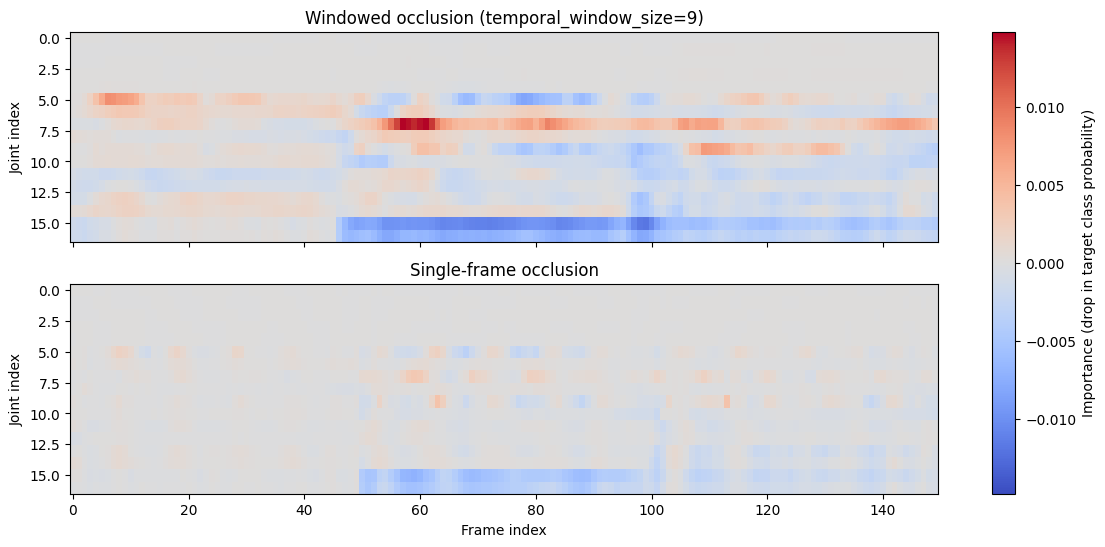


--- Summary statistics (person 0) ---
Windowed   -> mean abs: 0.00148, std: 0.00260, max abs: 0.01481
Single-fr. -> mean abs: 0.00045, std: 0.00098, max abs: 0.00714

Frame-to-frame variation (windowed):   0.00027
Frame-to-frame variation (single-fr.): 0.00020


In [6]:
import matplotlib.pyplot as plt
 
# --- pick a sample clip from the validation set ---
sample_index = 13  # change this to try different clips
pose_tensor, label = val_dataset[sample_index]
pose_tensor = pose_tensor.unsqueeze(0).to(device)  # [1, 3, 150, 17, 4]
 
print(f"Sample index: {sample_index}, label: {label}")
 
# --- run both occlusion variants ---
result_windowed = occlusion_windowed.explain(pose_tensor)
result_single = occlusion_single_frame.explain(pose_tensor)
 
joint_importance_windowed = result_windowed["joint_importance"]  # [T, V, M]
joint_importance_single = result_single["joint_importance"]      # [T, V, M]
 
print(f"Predicted class: {result_windowed['predicted_class']}")
 
# --- collapse to [T, V] for a single person to visualise as a heatmap ---
# picks the first present person (adjust if you want a specific one)
person_index = 0
 
heatmap_windowed = joint_importance_windowed[:, :, person_index].T.cpu().numpy()  # [V, T]
heatmap_single = joint_importance_single[:, :, person_index].T.cpu().numpy()      # [V, T]
 
# shared colour scale so the two heatmaps are directly comparable
vmax = max(abs(heatmap_windowed).max(), abs(heatmap_single).max())
vmin = -vmax
 
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
 
im0 = axes[0].imshow(heatmap_windowed, aspect="auto", cmap="coolwarm", vmin=vmin, vmax=vmax)
axes[0].set_title(f"Windowed occlusion (temporal_window_size={occlusion_windowed.temporal_window_size})")
axes[0].set_ylabel("Joint index")
 
im1 = axes[1].imshow(heatmap_single, aspect="auto", cmap="coolwarm", vmin=vmin, vmax=vmax)
axes[1].set_title("Single-frame occlusion")
axes[1].set_ylabel("Joint index")
axes[1].set_xlabel("Frame index")
 
fig.colorbar(im0, ax=axes, label="Importance (drop in target class probability)")
plt.savefig("occlusion_window_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
 
# --- quick summary stats to compare noisiness / magnitude ---
print("\n--- Summary statistics (person 0) ---")
print(f"Windowed   -> mean abs: {abs(heatmap_windowed).mean():.5f}, std: {heatmap_windowed.std():.5f}, max abs: {abs(heatmap_windowed).max():.5f}")
print(f"Single-fr. -> mean abs: {abs(heatmap_single).mean():.5f}, std: {heatmap_single.std():.5f}, max abs: {abs(heatmap_single).max():.5f}")
 
# frame-to-frame "noisiness": average absolute difference between consecutive frames
def frame_to_frame_variation(heatmap):
    diffs = heatmap[:, 1:] - heatmap[:, :-1]
    return abs(diffs).mean()
 
print(f"\nFrame-to-frame variation (windowed):   {frame_to_frame_variation(heatmap_windowed):.5f}")
print(f"Frame-to-frame variation (single-fr.): {frame_to_frame_variation(heatmap_single):.5f}")